In [ ]:

from pathlib import Path
import re, json, shutil, subprocess, itertools, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, confusion_matrix

warnings.filterwarnings("ignore")

cwd = Path.cwd().resolve()
candidates = [
    cwd,
    cwd.parent,
    Path("/mnt/data/fitness-convergence-mini"),
]
ROOT = None
for candidate in candidates:
    if (candidate / "data" / "sample" / "mini_fixture.csv").exists():
        ROOT = candidate
        break
if ROOT is None:
    raise FileNotFoundError(
        "Project root not found."
    )

DATA = ROOT / "data"
RAW = DATA / "raw"
PROCESSED = DATA / "processed"
RESULTS = ROOT / "results"
FIGURES = RESULTS / "figures"
for p in [RAW, PROCESSED, RESULTS, FIGURES]:
    p.mkdir(parents=True, exist_ok=True)

SOURCE_REPO = "https://github.com/DataWithAkaasha/youtube-trending-mini-project.git"

TOPICS = {
    "workout": ["workout","gym","fitness","training","exercise","cardio","strength","abs","squat","push up","pushup","running"],
    "body": ["weight loss","lose weight","fat loss","slim","muscle","bodybuilding","six pack","body transformation","burn fat"],
    "nutrition": ["protein","creatine","supplement","diet","meal prep","calorie","nutrition","healthy food"],
    "wellness": ["yoga","pilates","stretch","meditation","wellness","mobility"],
}
TOPIC_COLS = list(TOPICS)
COUNTRY_HINTS = {
    "pakistan":"PK","pak":"PK","pk":"PK",
    "india":"IN","ind":"IN","in":"IN",
    "germany":"DE","deutsch":"DE","de":"DE",
}

print("Project root:", ROOT)
print("Topics:", TOPIC_COLS)


Project root: .
Topics: ['workout', 'body', 'nutrition', 'wellness']


# Data Preprocessing

In [13]:

USE_PUBLIC_DATA = False

def download_public_dataset(force=False):
    target = RAW / "source_repo"
    if force and target.exists():
        shutil.rmtree(target)
    if not target.exists():
        subprocess.run(["git","clone","--depth","1",SOURCE_REPO,str(target)], check=True)
    csvs = sorted(target.rglob("*.csv"))
    if not csvs:
        raise FileNotFoundError("公开仓库已下载，但没有找到 CSV 文件。")
    return csvs

sample_path = DATA / "sample" / "mini_fixture.csv"

if USE_PUBLIC_DATA:
    try:
        paths = download_public_dataset()
        data_mode = "public"
        print(f"发现 {len(paths)} 个公开 CSV 文件。")
    except Exception as exc:
        print("公开数据下载失败，回退到本地 smoke-test 数据。")
        print("原因：", exc)
        paths = [sample_path]
        data_mode = "sample"
else:
    paths = [sample_path]
    data_mode = "sample"

print("Data mode:", data_mode)
for p in paths[:10]:
    print(" -", p)


Data mode: sample
 - data/sample/mini_fixture.csv


In [14]:

ALIASES = {
    "video_id":["video_id","video id"],
    "title":["title","video_title","video title"],
    "country":["country","region","country_code"],
    "views":["views","view_count","view count"],
    "likes":["likes","like_count","like count"],
    "comments":["comments","comment_count","comment count"],
    "publish_time":["publish_time","published_at","publish date","published date"],
}

def normalized_columns(frame):
    return {str(c).strip().lower(): c for c in frame.columns}

def match_column(frame, canonical):
    cols = normalized_columns(frame)
    for alias in ALIASES[canonical]:
        if alias in cols:
            return cols[alias]
    return None

def validate_frame(frame, name="data"):
    found = {k: match_column(frame, k) for k in ALIASES}
    required = ["title","views","likes","comments"]
    missing = [k for k in required if found[k] is None]
    if missing:
        raise ValueError(f"{name}: 缺少必要字段 {missing}; 实际字段={list(frame.columns)}")
    return found

def validate_files(file_paths):
    rows = []
    for p in file_paths:
        temp = pd.read_csv(p, nrows=200)
        found = validate_frame(temp, str(p))
        rows.append({"file":str(p),"rows_checked":len(temp),**{f"col_{k}":v for k,v in found.items()}})
    return pd.DataFrame(rows)

validation_report = validate_files(paths)
validation_report.to_csv(RESULTS / "validation_report.csv", index=False)
display(validation_report)
display(pd.read_csv(paths[0]).head(8))


,file,rows_checked,col_video_id,col_title,col_country,col_views,col_likes,col_comments,col_publish_time
0,...,36,video_id,title,country,views,likes,comments,publish_time


,video_id,title,channel,publish_time,views,likes,comments,country,date_collected
0,test001,20 Minute Full Body Workout,Sample Channel,2026-01-01T12:00:00Z,120000,6200,340,DE,2026-01-02
1,test002,Protein Breakfast Ideas,Sample Channel,2026-01-01T12:00:00Z,90000,5100,210,DE,2026-01-02
2,test003,Yoga for Beginners,Sample Channel,2026-01-01T12:00:00Z,80000,4200,180,DE,2026-01-02
3,test004,Daily News Update,Sample Channel,2026-01-01T12:00:00Z,200000,3000,500,DE,2026-01-02
4,test005,Strength Training Basics,Sample Channel,2026-01-01T12:00:00Z,110000,5800,260,DE,2026-01-02
5,test006,How to Lose Weight Safely,Sample Channel,2026-01-01T12:00:00Z,100000,4900,300,DE,2026-01-02
6,test007,Music Live Session,Sample Channel,2026-01-01T12:00:00Z,500000,12000,900,DE,2026-01-02
7,test008,Pilates Core Routine,Sample Channel,2026-01-01T12:00:00Z,70000,4000,150,DE,2026-01-02



## Theme Identification



- `workout`
- `body`
- `nutrition`
- `wellness`



In [15]:

def infer_country_from_path(path):
    text = str(path).lower().replace("_"," ").replace("-"," ")
    tokens = re.findall(r"[a-z]+", text)
    joined = " ".join(tokens)
    for key, code in COUNTRY_HINTS.items():
        if key in tokens or key in joined:
            return code
    return None

def first_existing(frame, found, key):
    col = found.get(key)
    if col is None:
        return pd.Series([np.nan] * len(frame), index=frame.index)
    return frame[col]

def normalize_one(path):
    raw = pd.read_csv(path)
    found = validate_frame(raw, str(path))
    out = pd.DataFrame()
    out["video_id"] = first_existing(raw, found, "video_id").astype(str)
    out["title"] = first_existing(raw, found, "title").fillna("").astype(str)
    out["views"] = pd.to_numeric(first_existing(raw, found, "views"), errors="coerce")
    out["likes"] = pd.to_numeric(first_existing(raw, found, "likes"), errors="coerce")
    out["comments"] = pd.to_numeric(first_existing(raw, found, "comments"), errors="coerce")
    out["publish_time"] = pd.to_datetime(first_existing(raw, found, "publish_time"), errors="coerce", utc=True)
    if found.get("country") is not None:
        out["country"] = raw[found["country"]].astype(str).str.upper().str.strip()
    else:
        out["country"] = infer_country_from_path(path)
    out["source_file"] = Path(path).name
    return out

def label_topics(title):
    text = str(title).lower()
    labels = {topic:int(any(word in text for word in words)) for topic, words in TOPICS.items()}
    labels["fitness_related"] = int(any(labels.values()))
    return labels

frames = [normalize_one(p) for p in paths]
df = pd.concat(frames, ignore_index=True)
n_before = len(df)

df = df.dropna(subset=["views","likes","comments","country"])
df = df[(df["views"]>0) & (df["likes"]>=0) & (df["comments"]>=0)].copy()
df = df.drop_duplicates(subset=["country","video_id","title"], keep="last")

labels = df["title"].apply(label_topics).apply(pd.Series)
df = pd.concat([df.reset_index(drop=True), labels.reset_index(drop=True)], axis=1)
df["engagement_rate"] = (df["likes"] + df["comments"]) / df["views"]
df["title_length"] = df["title"].str.len()
df["title_words"] = df["title"].str.split().str.len()
df.to_csv(PROCESSED / "videos_clean.csv", index=False)

print("原始记录数:", n_before)
print("清洗后记录数:", len(df))
print("健身相关记录数:", int(df["fitness_related"].sum()))
display(df.head(10))


原始记录数: 36
清洗后记录数: 36
健身相关记录数: 27


,video_id,title,views,likes,comments,publish_time,country,source_file,workout,body,nutrition,wellness,fitness_related,engagement_rate,title_length,title_words
0,test001,20 Minute Full Body Workout,120000,6200,340,2026-01-01 12:00:00+00:00,DE,mini_fixture.csv,1,0,0,0,1,0.054500,27,5
1,test002,Protein Breakfast Ideas,90000,5100,210,2026-01-01 12:00:00+00:00,DE,mini_fixture.csv,0,0,1,0,1,0.059000,23,3
2,test003,Yoga for Beginners,80000,4200,180,2026-01-01 12:00:00+00:00,DE,mini_fixture.csv,0,0,0,1,1,0.054750,18,3
3,test004,Daily News Update,200000,3000,500,2026-01-01 12:00:00+00:00,DE,mini_fixture.csv,0,0,0,0,0,0.017500,17,3
4,test005,Strength Training Basics,110000,5800,260,2026-01-01 12:00:00+00:00,DE,mini_fixture.csv,1,0,0,0,1,0.055091,24,3
5,test006,How to Lose Weight Safely,100000,4900,300,2026-01-01 12:00:00+00:00,DE,mini_fixture.csv,0,1,0,0,1,0.052000,25,5
6,test007,Music Live Session,500000,12000,900,2026-01-01 12:00:00+00:00,DE,mini_fixture.csv,0,0,0,0,0,0.025800,18,3
7,test008,Pilates Core Routine,70000,4000,150,2026-01-01 12:00:00+00:00,DE,mini_fixture.csv,0,0,0,1,1,0.059286,20,3
8,test009,Creatine Explained,60000,3500,170,2026-01-01 12:00:00+00:00,DE,mini_fixture.csv,0,0,1,0,1,0.061167,18,2
9,test010,Football Highlights,300000,9000,700,2026-01-01 12:00:00+00:00,DE,mini_fixture.csv,0,0,0,0,0,0.032333,19,2


# Compare accross Countries

,country,videos,fitness_videos,mean_views,mean_engagement,fitness_share
0,DE,12,9,147500.0000,0.0476,0.75
1,IN,12,9,309583.3333,0.0531,0.75
2,PK,12,9,173083.3333,0.0597,0.75


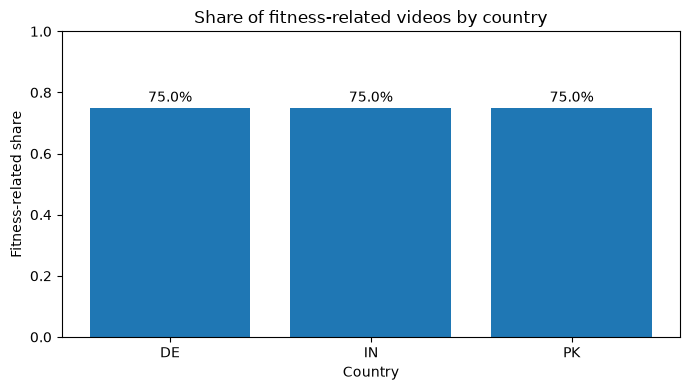

In [16]:

country_summary = (
    df.groupby("country")
      .agg(
          videos=("title","size"),
          fitness_videos=("fitness_related","sum"),
          mean_views=("views","mean"),
          mean_engagement=("engagement_rate","mean"),
      )
      .reset_index()
)
country_summary["fitness_share"] = country_summary["fitness_videos"] / country_summary["videos"]
country_summary.to_csv(PROCESSED / "country_summary.csv", index=False)
display(country_summary.round(4))

plot_df = country_summary.sort_values("fitness_share")
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(plot_df["country"], plot_df["fitness_share"])
ax.set_xlabel("Country")
ax.set_ylabel("Fitness-related share")
ax.set_title("Share of fitness-related videos by country")
ax.set_ylim(0, max(1.0, float(plot_df["fitness_share"].max()) * 1.15))
for i, v in enumerate(plot_df["fitness_share"]):
    ax.text(i, v + 0.02, f"{v:.1%}", ha="center")
fig.tight_layout()
fig.savefig(FIGURES / "fitness_share_notebook.png", dpi=160)
plt.show()


# Theme Profiling


,workout,body,nutrition,wellness
country,,,,
DE,0.222,0.111,0.333,0.333
IN,0.556,0.222,0.222,0.222
PK,0.444,0.222,0.222,0.222


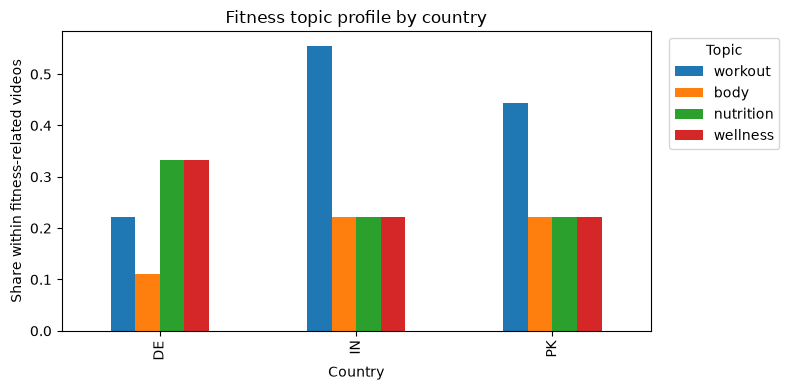

In [17]:

fitness_df = df[df["fitness_related"] == 1].copy()
if fitness_df.empty:
    raise ValueError("No fitness-related videos found. Please expand the topic keywords.")

topic_profile = fitness_df.groupby("country")[TOPIC_COLS].mean()
topic_profile.to_csv(PROCESSED / "topic_profile.csv")
display(topic_profile.round(3))

ax = topic_profile.plot(kind="bar", figsize=(8,4))
ax.set_xlabel("Country")
ax.set_ylabel("Share within fitness-related videos")
ax.set_title("Fitness topic profile by country")
ax.legend(title="Topic", bbox_to_anchor=(1.02,1), loc="upper left")
fig = ax.get_figure()
fig.tight_layout()
fig.savefig(FIGURES / "topic_profile_notebook.png", dpi=160)
plt.show()



## Similarity Analysis

country,DE,IN,PK
country,,,
DE,1.000,0.823,0.867
IN,0.823,1.000,0.994
PK,0.867,0.994,1.000


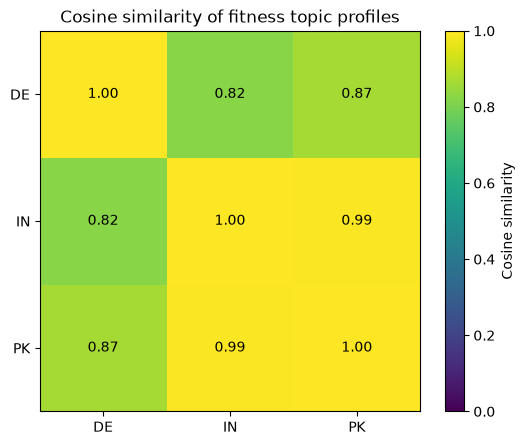

In [18]:

sim = pd.DataFrame(
    cosine_similarity(topic_profile),
    index=topic_profile.index,
    columns=topic_profile.index
)
sim.to_csv(PROCESSED / "country_similarity.csv")
display(sim.round(3))

fig, ax = plt.subplots(figsize=(5.5,4.5))
im = ax.imshow(sim.values, vmin=0, vmax=1)
ax.set_xticks(range(len(sim.columns)), sim.columns)
ax.set_yticks(range(len(sim.index)), sim.index)
ax.set_title("Cosine similarity of fitness topic profiles")
for i in range(len(sim.index)):
    for j in range(len(sim.columns)):
        ax.text(j, i, f"{sim.iloc[i,j]:.2f}", ha="center", va="center")
fig.colorbar(im, ax=ax, label="Cosine similarity")
fig.tight_layout()
fig.savefig(FIGURES / "country_similarity_notebook.png", dpi=160)
plt.show()



## 7. Bootstrap Stability


,country_pair,country_a,country_b,n_a,n_b,mean_similarity,ci_low,ci_high
0,DE-IN,DE,IN,9,9,0.686,0.263,0.979
1,DE-PK,DE,PK,9,9,0.714,0.269,0.981
2,IN-PK,IN,PK,9,9,0.828,0.465,0.979


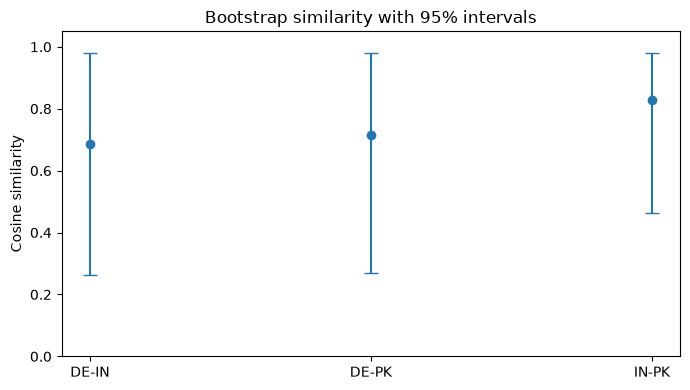

In [19]:

def bootstrap_similarity(data, n_boot=300, random_state=42):
    rng = np.random.default_rng(random_state)
    countries = sorted(data.loc[data["fitness_related"]==1,"country"].dropna().unique())
    records = []
    for a, b in itertools.combinations(countries, 2):
        da = data[(data["country"]==a) & (data["fitness_related"]==1)]
        db = data[(data["country"]==b) & (data["fitness_related"]==1)]
        if len(da)<2 or len(db)<2:
            continue
        scores = []
        for _ in range(n_boot):
            sa = da.iloc[rng.integers(0,len(da),len(da))][TOPIC_COLS].mean().to_numpy().reshape(1,-1)
            sb = db.iloc[rng.integers(0,len(db),len(db))][TOPIC_COLS].mean().to_numpy().reshape(1,-1)
            scores.append(float(cosine_similarity(sa,sb)[0,0]))
        records.append({
            "country_pair":f"{a}-{b}",
            "country_a":a,
            "country_b":b,
            "n_a":len(da),
            "n_b":len(db),
            "mean_similarity":float(np.mean(scores)),
            "ci_low":float(np.quantile(scores,0.025)),
            "ci_high":float(np.quantile(scores,0.975)),
        })
    return pd.DataFrame(records)

boot = bootstrap_similarity(df)
boot.to_csv(RESULTS / "bootstrap_similarity.csv", index=False)
display(boot.round(3))

if not boot.empty:
    x = np.arange(len(boot))
    means = boot["mean_similarity"].to_numpy()
    lower = means - boot["ci_low"].to_numpy()
    upper = boot["ci_high"].to_numpy() - means
    fig, ax = plt.subplots(figsize=(7,4))
    ax.errorbar(x, means, yerr=[lower,upper], fmt="o", capsize=5)
    ax.set_xticks(x, boot["country_pair"])
    ax.set_ylim(0,1.05)
    ax.set_ylabel("Cosine similarity")
    ax.set_title("Bootstrap similarity with 95% intervals")
    fig.tight_layout()
    fig.savefig(FIGURES / "bootstrap_similarity_notebook.png", dpi=160)
    plt.show()
else:
    print("No significant similarity found.")


# Exploratary Analysis

In [20]:

def train_engagement_model(data, random_state=42):
    work = data.copy()
    if len(work) < 20:
        return {"status":"skipped","reason":"fewer than 20 usable rows"}, None

    med = work.groupby("country")["engagement_rate"].transform("median")
    work["high_engagement"] = (work["engagement_rate"] > med).astype(int)

    X = work[["country","fitness_related","title_length","title_words"]]
    y = work["high_engagement"]

    if y.nunique()<2 or y.value_counts().min()<3:
        return {"status":"skipped","reason":"target classes are too small"}, None

    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=0.30, random_state=random_state, stratify=y
    )

    pre = ColumnTransformer([
        ("country", OneHotEncoder(handle_unknown="ignore"), ["country"]),
        ("num", StandardScaler(), ["fitness_related","title_length","title_words"]),
    ])
    model = Pipeline([
        ("pre", pre),
        ("clf", LogisticRegression(max_iter=1000)),
    ])
    model.fit(Xtr,ytr)
    pred = model.predict(Xte)
    prob = model.predict_proba(Xte)[:,1]

    metrics = {
        "status":"ok",
        "n_train":int(len(Xtr)),
        "n_test":int(len(Xte)),
        "accuracy":float(accuracy_score(yte,pred)),
        "balanced_accuracy":float(balanced_accuracy_score(yte,pred)),
        "roc_auc":float(roc_auc_score(yte,prob)),
        "confusion_matrix":confusion_matrix(yte,pred).tolist(),
        "note":"Exploratory model only; high engagement is defined relative to each country's median."
    }
    return metrics, model

model_metrics, model = train_engagement_model(df)
(RESULTS / "model_metrics.json").write_text(json.dumps(model_metrics, indent=2), encoding="utf-8")
print(json.dumps(model_metrics, indent=2))


{
  "status": "ok",
  "n_train": 25,
  "n_test": 11,
  "accuracy": 0.6363636363636364,
  "balanced_accuracy": 0.6666666666666666,
  "roc_auc": 0.6333333333333333,
  "confusion_matrix": [
    [
      2,
      4
    ],
    [
      0,
      5
    ]
  ],
  "note": "Exploratory model only; high engagement is defined relative to each country's median."
}


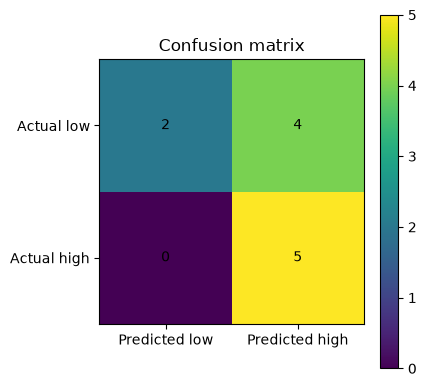

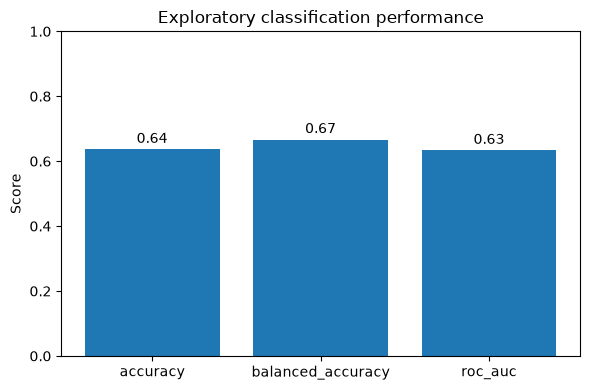

In [21]:

if model_metrics.get("status") == "ok":
    cm = np.array(model_metrics["confusion_matrix"])
    fig, ax = plt.subplots(figsize=(4.5,4))
    im = ax.imshow(cm)
    ax.set_xticks([0,1], ["Predicted low","Predicted high"])
    ax.set_yticks([0,1], ["Actual low","Actual high"])
    ax.set_title("Confusion matrix")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j,i,str(cm[i,j]),ha="center",va="center")
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    fig.savefig(FIGURES / "confusion_matrix_notebook.png", dpi=160)
    plt.show()

    names = ["accuracy","balanced_accuracy","roc_auc"]
    values = [model_metrics[n] for n in names]
    fig, ax = plt.subplots(figsize=(6,4))
    ax.bar(names, values)
    ax.set_ylim(0,1)
    ax.set_ylabel("Score")
    ax.set_title("Exploratory classification performance")
    for i,v in enumerate(values):
        ax.text(i,v+0.02,f"{v:.2f}",ha="center")
    fig.tight_layout()
    fig.savefig(FIGURES / "model_metrics_notebook.png", dpi=160)
    plt.show()
else:
    print("模型实验未执行：", model_metrics.get("reason"))


In [22]:

print("=== Pipeline summary ===")
print("Data mode:", data_mode)
print("Clean rows:", len(df))
print("Countries:", sorted(df["country"].dropna().unique().tolist()))
print("Fitness-related rows:", int(df["fitness_related"].sum()))
print("Generated figures:")
for p in sorted(FIGURES.glob("*_notebook.png")):
    print(" -", p.name)
print("\nNotebook pipeline completed successfully.")


=== Pipeline summary ===
Data mode: sample
Clean rows: 36
Countries: ['DE', 'IN', 'PK']
Fitness-related rows: 27
Generated figures:
 - bootstrap_similarity_notebook.png
 - confusion_matrix_notebook.png
 - country_similarity_notebook.png
 - fitness_share_notebook.png
 - model_metrics_notebook.png
 - topic_profile_notebook.png

Notebook pipeline completed successfully.
